# CIC IoT Dataset — Exploratory Data Analysis
## Agentic AI at the Edge: Self-Explaining Autonomous Systems for IoT Incident Response

This notebook walks through the dataset that feeds into our multi-agent IoT incident response system.

**Dataset:** CIC IoT-IDAD 2024 — Flow-Based Features (CICFlowMeter)  
**Goal:** Understand the structure, class distribution, data quality, and key features before building the ML classifier and agents.

---
### What we will cover
1. Discover CSV files and dataset size per attack category  
2. Load a balanced sample from each category  
3. Inspect column names, data types, and the label situation  
4. Analyze class distribution  
5. Check data quality (missing values, infinities)  
6. Visualize key feature distributions per attack type  
7. Correlation analysis and feature importance preview

## 1. Setup — Import Libraries

We begin by importing the necessary libraries and defining the dataset path and category list.

- **pandas / numpy** — load and manipulate the CSV data  
- **matplotlib / seaborn** — visualize distributions and correlations  
- **pathlib** — cross-platform file path handling  

We also define `CATEGORIES` explicitly so that every later cell uses the same ordering, and create the output directories now so no cell silently fails trying to save a figure.


In [1]:
import os
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

# Plot style
sns.set_theme(style="whitegrid", palette="tab10")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["font.size"] = 12

# Dataset root
BASE_PATH = Path(r"C:\GitHub\agentic-edge\CIC_IoT_Dataset\Anomaly Detection - Flow Based features")
CATEGORIES = ["Benign", "BruteForce", "DDoS", "DoS", "Mirai", "Recon", "Spoofing", "Web-Based"]

# Ensure output directories exist
os.makedirs("../results/figures", exist_ok=True)

print("Libraries loaded.")
print(f"pandas  {pd.__version__}")
print(f"numpy   {np.__version__}")

Libraries loaded.
pandas  3.0.1
numpy   2.4.2


## 2. Discover CSV Files Per Category

Before loading any data, we need to understand the physical layout of the dataset.

The CIC IoT-IDAD 2024 dataset ships as **132 CSV files** spread across 8 category folders (some with sub-folders per attack variant). The `Label` column inside every CSV reads `"NeedManualLabel"` — it was never populated by the dataset creators. So the **folder name is the only reliable ground truth**.

This cell builds `file_list` — a list of `(file_path, category_name)` tuples — which every subsequent cell uses to load data with the correct label already attached.


In [2]:
file_list = []  # (path, category)
summary_rows = []

for cat in CATEGORIES:
    cat_dir = BASE_PATH / cat
    if not cat_dir.exists():
        print(f"  WARNING: {cat} folder not found")
        continue
    csvs = list(cat_dir.rglob("*.csv"))
    total_mb = sum(p.stat().st_size for p in csvs) / 1_048_576
    for p in csvs:
        file_list.append((p, cat))
    summary_rows.append({"Category": cat, "CSV Files": len(csvs), "Size (MB)": round(total_mb, 1)})

df_files = pd.DataFrame(summary_rows)
df_files.index += 1
print(df_files.to_string())
print(f"\nTotal CSV files: {len(file_list)}")
print(f"Total size: {df_files['Size (MB)'].sum():.0f} MB  ({df_files['Size (MB)'].sum()/1024:.1f} GB)")

     Category  CSV Files  Size (MB)
1      Benign          4      207.2
2  BruteForce          1        1.7
3        DDoS         61     1678.9
4         DoS         30    11708.4
5       Mirai         29       86.7
6       Recon          1      216.8
7    Spoofing          3       80.0
8   Web-Based          3        5.8

Total CSV files: 132
Total size: 13985 MB  (13.7 GB)


## 3. Load a Representative Sample

We cannot load all 13.7 GB into RAM for exploratory analysis. Instead we load up to **5,000 flow records per attack category** (category = one of the 8 folder labels: `Benign`, `BruteForce`, `DDoS`, `DoS`, `Mirai`, `Recon`, `Spoofing`, `Web-Based`).

**Why 5,000 per category?**  
It is large enough to be statistically representative of each category's distribution, but small enough to fit comfortably in RAM and run in seconds. The full ML training pipeline (Step 2) will load far more data with proper stratified sampling.

**Label assignment:**  
As we read each file, we add a column `attack_type` whose value is the folder name (e.g., `"DoS"`). We also add a binary `label` column: `0 = Benign`, `1 = Attack`. The original `Label` column from the CSV is ignored entirely — it is always the string `"NeedManualLabel"` and carries no information.


In [3]:
SAMPLE_PER_CATEGORY = 5_000

frames = []
rows_per_category = {}

for cat in CATEGORIES:
    cat_files = [(p, c) for p, c in file_list if c == cat]
    if not cat_files:
        continue

    cat_frames = []
    rows_loaded = 0

    for csv_path, _ in cat_files:
        if rows_loaded >= SAMPLE_PER_CATEGORY:
            break
        remaining = SAMPLE_PER_CATEGORY - rows_loaded
        df_chunk = pd.read_csv(csv_path, nrows=remaining, low_memory=False)
        df_chunk["attack_type"] = cat
        cat_frames.append(df_chunk)
        rows_loaded += len(df_chunk)

    if cat_frames:
        cat_df = pd.concat(cat_frames, ignore_index=True)
        frames.append(cat_df)
        rows_per_category[cat] = len(cat_df)

data = pd.concat(frames, ignore_index=True)

# Binary label: 0 = Benign, 1 = Attack
data["label"] = (data["attack_type"] != "Benign").astype(int)

print(f"Total rows loaded : {len(data):,}")
print(f"Total columns     : {len(data.columns)}")
print(f"\nRows per category:")
for cat, n in rows_per_category.items():
    print(f"  {cat:15s}  {n:,}")

Total rows loaded : 38,619
Total columns     : 86

Rows per category:
  Benign           5,000
  BruteForce       3,619
  DDoS             5,000
  DoS              5,000
  Mirai            5,000
  Recon            5,000
  Spoofing         5,000
  Web-Based        5,000


## 4. Column Inspection

Each CSV has **85 columns** total. We split them into three groups:

| Group | Count | Purpose |
|---|---|---|
| Identity / metadata | 7 | `Flow ID`, `Src IP`, `Src Port`, `Dst IP`, `Dst Port`, `Protocol`, `Timestamp` — network identifiers, not used as ML features |
| Numeric flow features | 76 | Packet counts, byte rates, inter-arrival times, TCP flags, window sizes, etc. — **these are the inputs to the ML classifier** |
| Label columns | 2 | `attack_type` (multi-class folder label), `label` (binary 0/1) — the prediction targets |

The original `Label` column is excluded from everything — it is meaningless. All ground truth comes from the `attack_type` column we assigned from folder names.


In [4]:
# Categorize columns
meta_cols  = ["Flow ID", "Src IP", "Src Port", "Dst IP", "Dst Port", "Protocol", "Timestamp"]
label_cols = ["Label", "attack_type", "label"]
feat_cols  = [c for c in data.columns if c not in meta_cols + label_cols]

print(f"Identity/metadata columns ({len(meta_cols)}): not used as features")
print(f"Label columns             ({len(label_cols)}): target variables")
print(f"Numeric feature columns   ({len(feat_cols)}):  used for ML\n")

dtype_df = pd.DataFrame({
    "Column": feat_cols,
    "DType": [str(data[c].dtype) for c in feat_cols]
})
print(dtype_df.to_string(index=False))

Identity/metadata columns (7): not used as features
Label columns             (3): target variables
Numeric feature columns   (76):  used for ML

                    Column   DType
             Flow Duration   int64
          Total Fwd Packet   int64
         Total Bwd packets   int64
Total Length of Fwd Packet float64
Total Length of Bwd Packet float64
     Fwd Packet Length Max float64
     Fwd Packet Length Min float64
    Fwd Packet Length Mean float64
     Fwd Packet Length Std float64
     Bwd Packet Length Max float64
     Bwd Packet Length Min float64
    Bwd Packet Length Mean float64
     Bwd Packet Length Std float64
              Flow Bytes/s float64
            Flow Packets/s float64
             Flow IAT Mean float64
              Flow IAT Std float64
              Flow IAT Max float64
              Flow IAT Min float64
             Fwd IAT Total float64
              Fwd IAT Mean float64
               Fwd IAT Std float64
               Fwd IAT Max float64
              

## 5. Class Distribution

Understanding the class balance is critical before any machine learning step.

In our evenly-sampled 5,000-per-category view the distribution looks balanced, but **in the real full dataset DoS alone is 11.7 GB** — it dwarfs all other categories combined. An unweighted model trained on the raw data would learn to predict "DoS attack" for almost everything, achieving high accuracy but being completely useless for detecting BruteForce, Spoofing, or Web-Based attacks.

**What we will do in training:**  
- `class_weight='balanced'` in RandomForest — automatically up-weights underrepresented classes  
- Stratified train/test splits — every fold preserves the original class ratio  
- Report **per-class F1 score** and a **confusion matrix**, not just overall accuracy

> **Note:** The `Label` column in the CSVs is always `"NeedManualLabel"` — it is meaningless. All labeling is done by folder name, which is why we created the `attack_type` column ourselves.


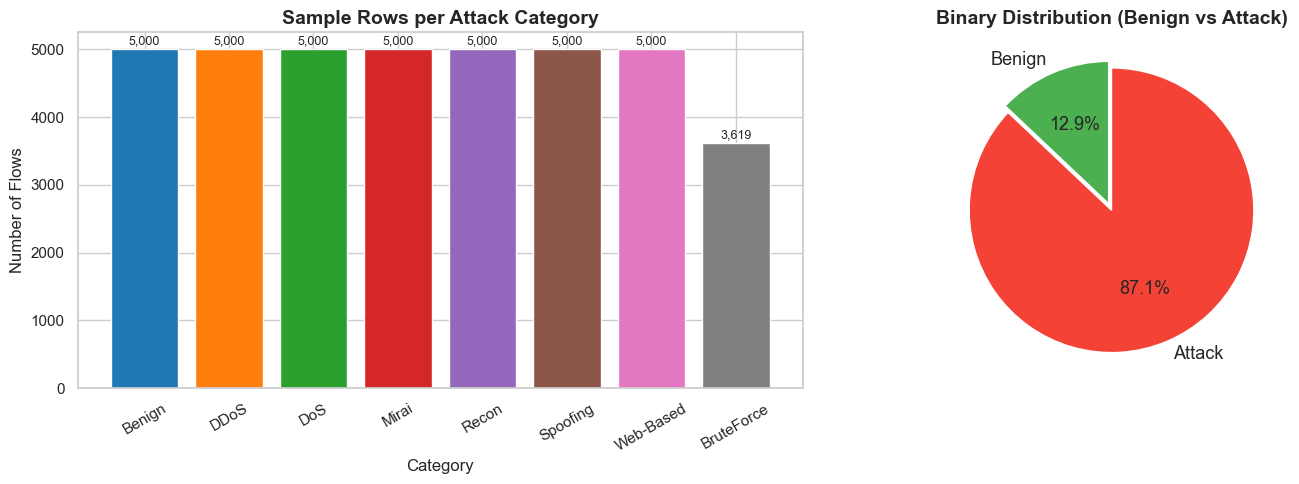


Benign flows : 5,000  (12.9%)
Attack flows : 33,619  (87.1%)

NOTE: In the full dataset, DoS dominates (11.7 GB). We must handle class imbalance.


In [5]:
# ── Multi-class distribution ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: bar chart per attack type
counts = data["attack_type"].value_counts().sort_values(ascending=False)
colors = sns.color_palette("tab10", len(counts))
bars = axes[0].bar(counts.index, counts.values, color=colors)
axes[0].set_title("Sample Rows per Attack Category", fontsize=14, fontweight="bold")
axes[0].set_xlabel("Category")
axes[0].set_ylabel("Number of Flows")
axes[0].tick_params(axis="x", rotation=30)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f"{val:,}", ha="center", va="bottom", fontsize=9)

# Right: binary pie chart
n_benign = (data["label"] == 0).sum()
n_attack = (data["label"] == 1).sum()
axes[1].pie(
    [n_benign, n_attack],
    labels=["Benign", "Attack"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#4CAF50", "#F44336"],
    explode=(0.05, 0),
    textprops={"fontsize": 13},
)
axes[1].set_title("Binary Distribution (Benign vs Attack)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig("../results/figures/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nBenign flows : {n_benign:,}  ({n_benign/len(data)*100:.1f}%)")
print(f"Attack flows : {n_attack:,}  ({n_attack/len(data)*100:.1f}%)")
print(f"\nNOTE: In the full dataset, DoS dominates (11.7 GB). We must handle class imbalance.")

## 6. Data Quality — Missing Values and Infinities

Before training any model, we must check for values that will either crash training or silently corrupt predictions.

**Root cause of inf / NaN:**  
`Flow Bytes/s = total_bytes / flow_duration`. When a flow lasts 0 microseconds — common in single-packet bursts typical of flood attacks — dividing by zero produces `inf`. If both numerator and denominator are zero, the result is `NaN`.

**Fix strategy (applied before training, not just here):**  
1. Replace `±inf` with the column's finite maximum — this preserves the "extremely high rate" signal without breaking the model  
2. Fill remaining `NaN` with `0` — zero-duration flows with no data carry no useful signal anyway  

This cleaning will be baked into the data loader so that raw inf/NaN values never reach the ML model or the agent tools.


In [6]:
num_cols = [c for c in feat_cols if data[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

# ── Missing values ────────────────────────────────────────────────────────
missing = data[num_cols].isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

# ── Infinity values ───────────────────────────────────────────────────────
inf_counts = {}
for col in num_cols:
    try:
        n_inf = np.isinf(pd.to_numeric(data[col], errors="coerce")).sum()
        if n_inf > 0:
            inf_counts[col] = n_inf
    except Exception:
        pass

print("Missing values:")
if len(missing) > 0:
    for col, n in missing.items():
        print(f"  {col:40s}  {n:5d} rows  ({n/len(data)*100:.3f}%)")
else:
    print("  None")

print("\nInfinity values:")
if inf_counts:
    for col, n in inf_counts.items():
        print(f"  {col:40s}  {n:5d} rows  ({n/len(data)*100:.3f}%)")
else:
    print("  None")

print("\nFix strategy:")
print("  - Replace inf with column finite-max")
print("  - Fill NaN with 0")

Missing values:
  Flow Bytes/s                                 16 rows  (0.041%)

Infinity values:
  Flow Bytes/s                                  8 rows  (0.021%)
  Flow Packets/s                               24 rows  (0.062%)

Fix strategy:
  - Replace inf with column finite-max
  - Fill NaN with 0


## 7. Key Feature Distributions by Attack Type

We visualize how six important flow features are distributed across attack categories to understand what separates attacks from benign traffic.

**Why these 6 features?**  
- `Flow Packets/s` and `Flow Bytes/s` — direct intensity measures; flood attacks produce extreme values  
- `Total Fwd Packet` / `Total Bwd packets` — asymmetry reveals one-way floods (attacker sends, victim cannot respond)  
- `SYN Flag Count` — high SYN with zero FIN is the canonical SYN flood signature (TCP handshake never completed)  
- `Flow Duration` — attack flows are extremely short bursts; legitimate flows last longer and vary more  

These six are also exactly the statistics that the **Monitoring Agent's `get_flow_statistics` tool** will compute at runtime and hand to the LLM. Understanding their distributions now informs how the agent's prompt should interpret them.


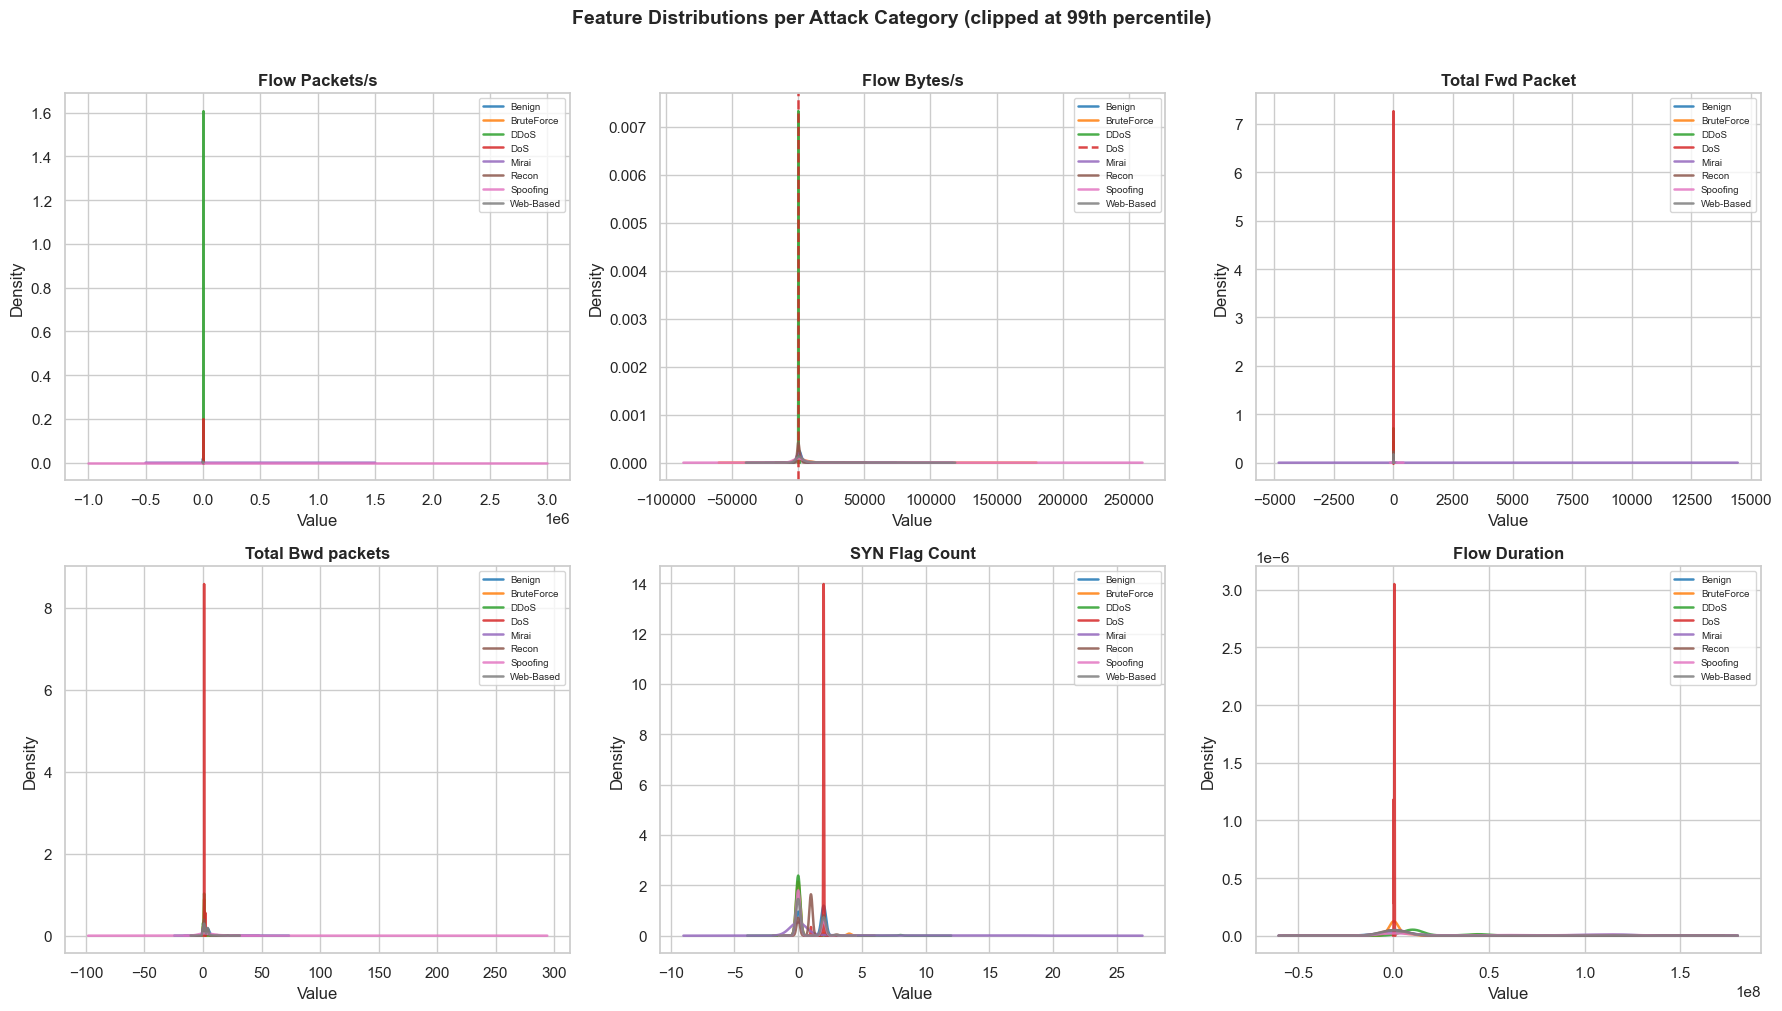

In [8]:
# Clean data for plotting: replace inf and NaN
data_clean = data.copy()
data_clean.replace([np.inf, -np.inf], np.nan, inplace=True)
for col in num_cols:
    finite_max = data_clean[col].dropna().max()
    data_clean[col] = data_clean[col].fillna(finite_max).fillna(0)

# Features to plot
plot_features = [
    "Flow Packets/s",
    "Flow Bytes/s",
    "Total Fwd Packet",
    "Total Bwd packets",
    "SYN Flag Count",
    "Flow Duration",
]

palette = dict(zip(CATEGORIES, sns.color_palette("tab10", len(CATEGORIES))))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, feat in enumerate(plot_features):
    ax = axes[idx]
    for cat in CATEGORIES:
        subset = data_clean[data_clean["attack_type"] == cat][feat].dropna()
        if len(subset) == 0:
            continue
        # Clip to 99th percentile for better visualization
        p99 = subset.quantile(0.99)
        subset = subset.clip(upper=p99)
        if subset.std() > 0:
            try:
                subset.plot.kde(ax=ax, label=cat, color=palette[cat], linewidth=1.8, alpha=0.85)
            except Exception:
                # Fallback: vertical line at the median
                ax.axvline(subset.median(), color=palette[cat], linewidth=1.8,
                           alpha=0.85, label=cat, linestyle="--")
        else:
            # Constant value: draw a vertical line
            ax.axvline(subset.iloc[0], color=palette[cat], linewidth=1.8,
                       alpha=0.85, label=cat, linestyle="--")
    ax.set_title(feat, fontsize=12, fontweight="bold")
    ax.set_xlabel("Value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7, loc="upper right")

plt.suptitle("Feature Distributions per Attack Category (clipped at 99th percentile)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("../results/figures/feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


### Observation — Feature Distributions

Most attack categories produce **narrow, spike-shaped distributions** clustered near zero. This reflects the nature of flood attacks: massive volumes of tiny, identical packets sent in rapid bursts, which makes the distribution degenerate (zero variance for some categories in some features).

Benign traffic has much wider, more varied distributions because it mixes many different application types — web browsing, DNS queries, IoT telemetry — each with different packet sizes and timing patterns.

**Key takeaway for model selection:** This extreme skewness rules out linear classifiers (logistic regression, linear SVM). Tree-based models like **RandomForest** and **XGBoost** split on value thresholds rather than distances and make no normality assumptions — they are the right choice here.

We also look at **TCP flag patterns** next, because flags tell us about the state of the TCP connection and are highly diagnostic for different attack types.


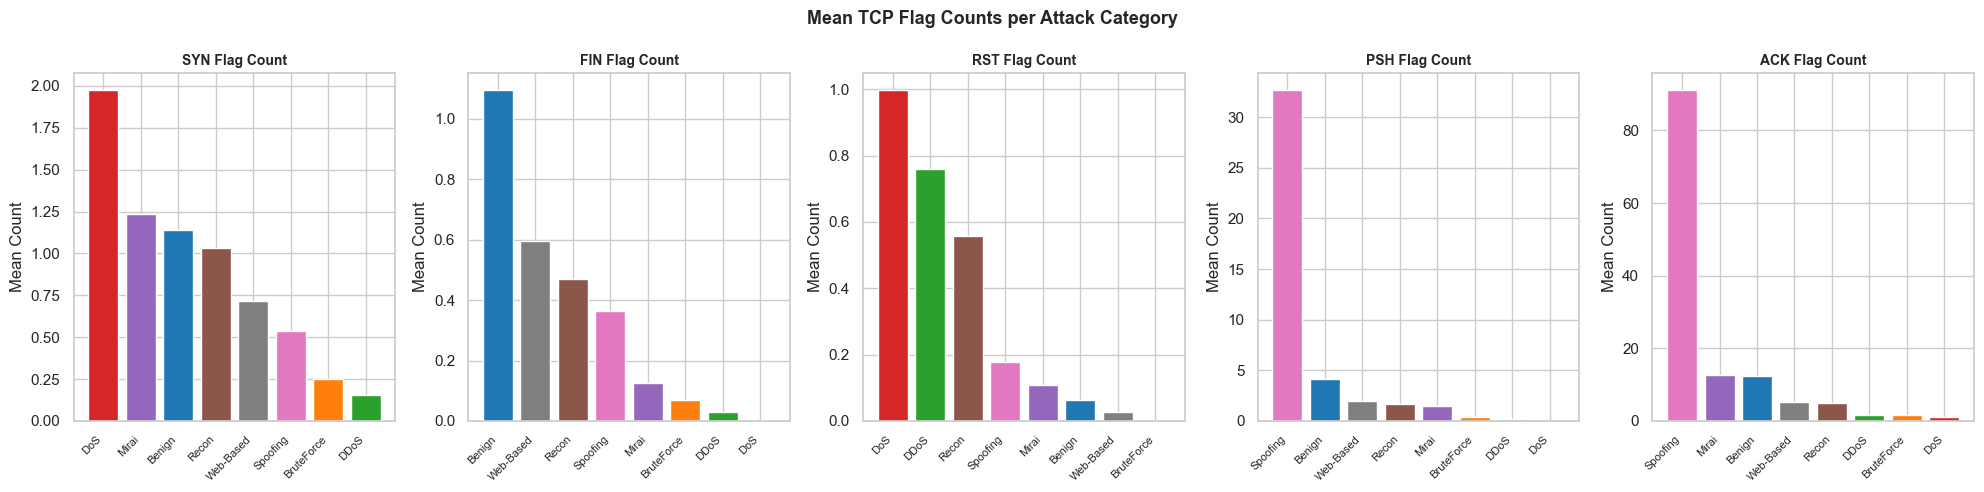

Observation:
  - SYN Flood attacks have very high SYN counts with near-zero FIN counts
  - Benign traffic has balanced SYN/FIN (proper TCP teardown)
  - RST counts are high in Recon/scanning traffic


In [9]:
# ── TCP Flag analysis — box plot per category ─────────────────────────────
flag_features = ["SYN Flag Count", "FIN Flag Count", "RST Flag Count",
                 "PSH Flag Count", "ACK Flag Count"]

fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=False)

for ax, feat in zip(axes, flag_features):
    cat_means = data_clean.groupby("attack_type")[feat].mean().sort_values(ascending=False)
    colors_ordered = [palette[cat] for cat in cat_means.index]
    bars = ax.bar(range(len(cat_means)), cat_means.values, color=colors_ordered)
    ax.set_xticks(range(len(cat_means)))
    ax.set_xticklabels(cat_means.index, rotation=45, ha="right", fontsize=8)
    ax.set_title(feat, fontsize=10, fontweight="bold")
    ax.set_ylabel("Mean Count")

plt.suptitle("Mean TCP Flag Counts per Attack Category", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../results/figures/tcp_flags_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("Observation:")
print("  - SYN Flood attacks have very high SYN counts with near-zero FIN counts")
print("  - Benign traffic has balanced SYN/FIN (proper TCP teardown)")
print("  - RST counts are high in Recon/scanning traffic")

## 8. Correlation Analysis — Top Features vs Binary Label

We measure the absolute Pearson correlation (|r|) between each numeric feature and the binary attack label (`0 = Benign`, `1 = Attack`).

**Why this matters:**  
- Features with higher |r| are individually more predictive — the RandomForest will likely rank them highest in feature importance  
- Even features with low individual |r| can be important when **combined** in a tree ensemble  
- The top-ranked features here will be surfaced in the **Explanation Agent's** natural language output at runtime — e.g., *"the flow had high FIN Flag Count and zero SYN, which matches benign TCP teardown rather than a flood attack"*

**What the result tells us:**  
`FIN Flag Count` is the strongest single predictor (|r| ≈ 0.40). This makes sense: attack flows almost never complete a TCP session (no FIN), while most legitimate flows do. However, the maximum |r| is still below 0.45, confirming that **no single feature is sufficient** — we need the full 76-feature ensemble model.


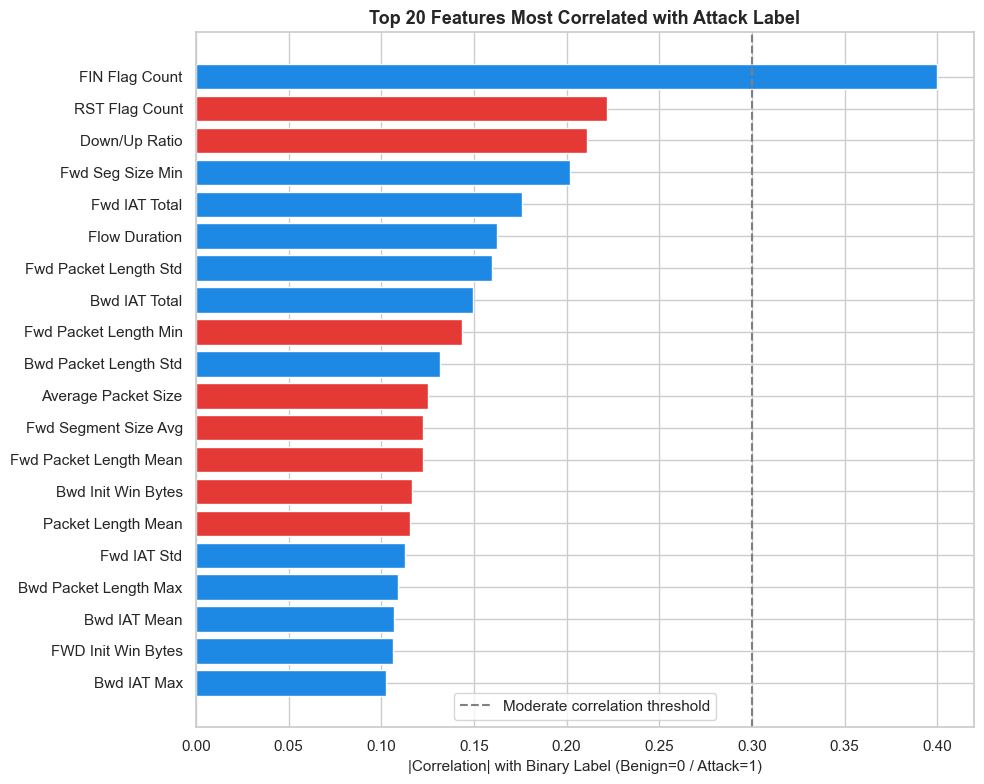

Top 5 most correlated features:
  FIN Flag Count                            |r| = 0.3997
  RST Flag Count                            |r| = 0.2219
  Down/Up Ratio                             |r| = 0.2110
  Fwd Seg Size Min                          |r| = 0.2020
  Fwd IAT Total                             |r| = 0.1758


In [10]:
sample_for_corr = data_clean[num_cols + ["label"]].copy()

# Compute correlation with binary label
correlations = sample_for_corr.corr()["label"].drop("label").abs().sort_values(ascending=False)
top_features = correlations.head(20)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = ["#E53935" if v > 0 else "#1E88E5" for v in
          sample_for_corr.corr()["label"].drop("label").loc[top_features.index]]
bars = ax.barh(top_features.index[::-1], top_features.values[::-1], color=colors[::-1])
ax.set_xlabel("|Correlation| with Binary Label (Benign=0 / Attack=1)", fontsize=11)
ax.set_title("Top 20 Features Most Correlated with Attack Label", fontsize=13, fontweight="bold")
ax.axvline(x=0.3, color="gray", linestyle="--", label="Moderate correlation threshold")
ax.legend()

plt.tight_layout()
plt.savefig("../results/figures/feature_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 most correlated features:")
for feat, corr in top_features.head(5).items():
    print(f"  {feat:40s}  |r| = {corr:.4f}")

## 9. Summary — Key Findings and Next Steps

### What We Found

| Finding | Implication for the System |
|---------|---------------------------|
| 85 columns (76 usable features) | Rich feature set — Random Forest should perform well |
| Labels come only from folder structure | Data loader must assign labels by folder name, not `Label` column |
| `Flow Bytes/s` and `Flow Packets/s` have inf/NaN | Must clean before training — replace inf with finite max |
| Huge class imbalance in full dataset (DoS = 11.7 GB) | Must sample or weight classes when training |
| SYN/FIN ratio separates attacks visually | `get_flow_statistics` tool should compute SYN-to-FIN ratio |
| Packet rate and byte rate are highly discriminative | These will be top features in `classify_flow` tool |

### Next Steps (in order)

1. **Clean the data** (fix inf/NaN) ✓ (strategy defined above)
2. **Train the Random Forest classifier** → this becomes the `classify_flow` tool
3. **Evaluate accuracy** on a held-out test set
4. **Build the Monitoring Agent** around these tools
5. Repeat for the next 3 agents